**Model Tuning**

In [8]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop((64, 64), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.GaussianBlur(3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    normalize
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    normalize
])

train_dataset.transform = train_transform
test_dataset.transform = test_transform

Show Image Without Normalization for Visualization

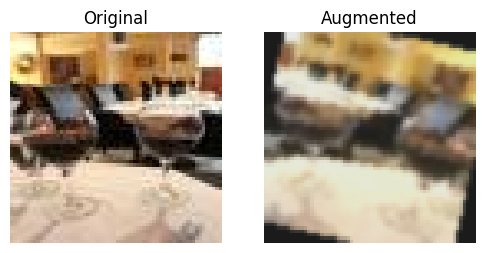

In [9]:
import matplotlib.pyplot as plt
import torchvision
from PIL import Image

# Get the first image path
orig_path, _ = train_dataset.samples[0]
original_img = Image.open(orig_path).convert("RGB")

# Define augmentation WITHOUT normalization (for visualization only)
vis_transform = transforms.Compose([
    transforms.RandomResizedCrop((64, 64), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.GaussianBlur(3, sigma=(0.1, 1.0)),
    transforms.ToTensor()
])

# Apply augmentation once
augmented_img = vis_transform(original_img)

# Plot side by side
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(torchvision.transforms.functional.to_pil_image(augmented_img))
plt.title("Augmented")
plt.axis("off")

plt.show()


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [12]:
# Define diffusion parameters
def cosine_beta_schedule(timesteps, s=0.008):
    steps = torch.arange(timesteps+1, dtype=torch.float64) / timesteps
    alphas_cumprod = torch.cos((steps + s) / (1+s) * torch.pi * 0.5)**2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

T = 200
betas = cosine_beta_schedule(T).to(device).float()
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod).float()
sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod).float()



In [13]:
def q_sample(x_start, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x_start).float()  # ensure float32
    return (
        sqrt_alphas_cumprod[t][:, None, None, None] * x_start +
        sqrt_one_minus_alphas_cumprod[t][:, None, None, None] * noise
    )


In [14]:
##✅ 3. EMA Class
class EMA:
    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow_params = [p.clone().detach() for p in model.parameters()]

    def update(self):
        for shadow, param in zip(self.shadow_params, self.model.parameters()):
            shadow.data = self.decay * shadow.data + (1.0 - self.decay) * param.data

    def apply_shadow(self):
        for shadow, param in zip(self.shadow_params, self.model.parameters()):
            param.data.copy_(shadow.data)

In [15]:
# ✅ Residual Block for UNet
def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.GroupNorm(8, out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        nn.GroupNorm(8, out_ch)
    )

In [16]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = conv_block(in_ch, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return F.relu(self.block(x) + self.skip(x))


In [17]:
## ✅ Self-Attention Block
class SelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.query = nn.Conv2d(channels, channels // 8, 1)
        self.key = nn.Conv2d(channels, channels // 8, 1)
        self.value = nn.Conv2d(channels, channels, 1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.size()
        q = self.query(x).view(B, -1, H * W)
        k = self.key(x).view(B, -1, H * W)
        v = self.value(x).view(B, -1, H * W)

        attn = torch.bmm(q.permute(0, 2, 1), k)  # [B, HW, HW]
        attn = F.softmax(attn, dim=-1)

        out = torch.bmm(v, attn.permute(0, 2, 1))
        out = out.view(B, C, H, W)
        return self.gamma * out + x


In [18]:
class TunedUNet(nn.Module):
    def __init__(self, in_channels=3, time_dim=64):
        super().__init__()

        self.time_mlp = nn.Sequential(
            SinusoidalPosEmb(time_dim),
            nn.Linear(time_dim, time_dim * 4),
            nn.ReLU(),
            nn.Linear(time_dim * 4, time_dim)
        )

        # Encoder
        self.enc1 = ResidualBlock(in_channels, 64)
        self.enc2 = ResidualBlock(64, 128)
        self.enc3 = ResidualBlock(128, 256)

        self.down = nn.MaxPool2d(2)

        # Bottleneck with Self-Attention
        self.bottleneck = nn.Sequential(
            ResidualBlock(256, 512),
            SelfAttention(512)
        )

        # Decoder
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec1 = ResidualBlock(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ResidualBlock(256, 128)

        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)   # ✅ New upsample
        self.dec3 = ResidualBlock(128, 64)                    # ✅ New residual block

        self.final_conv = nn.Conv2d(64, in_channels, 3, padding=1)

        self.time_proj1 = nn.Linear(time_dim, 64)
        self.time_proj2 = nn.Linear(time_dim, 128)
        self.time_proj3 = nn.Linear(time_dim, 256)

    def forward(self, x, t):
        t_emb = self.time_mlp(t)

        # Encoder
        x1 = self.enc1(x) + self.time_proj1(t_emb)[:, :, None, None]
        x2 = self.down(x1)
        x2 = self.enc2(x2) + self.time_proj2(t_emb)[:, :, None, None]
        x3 = self.down(x2)
        x3 = self.enc3(x3) + self.time_proj3(t_emb)[:, :, None, None]

        bottleneck = self.bottleneck(self.down(x3))

        # Decoder
        x = self.up1(bottleneck)
        x = torch.cat([x, x3], dim=1)
        x = self.dec1(x)

        x = self.up2(x)
        x = torch.cat([x, x2], dim=1)
        x = self.dec2(x)

        x = self.up3(x)                               # ✅ New stage
        x = torch.cat([x, x1], dim=1)                 # ✅ Connect skip connection
        x = self.dec3(x)

        return self.final_conv(x)                     # ✅ Final output 64×64


In [25]:
import math  # ✅ Add this
import torch
import torch.nn as nn

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)  # <-- math.log used here
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)
        return emb


In [21]:
##Initialize model, optimizer, and EMA
tuned_model = TunedUNet().to(device)
optimizer = optim.AdamW(tuned_model.parameters(), lr=1e-4)
ema = EMA(tuned_model)

print(f"Model parameters: {sum(p.numel() for p in tuned_model.parameters())/1e6:.2f}M")


Model parameters: 8.44M


In [31]:
import time

def train_ddpm(model, dataloader, optimizer, epochs, time_limit=7 * 60 * 60):
    model.train()
    start_time = time.time()

    for epoch in range(epochs):
        if time.time() - start_time > time_limit:
            print("⏰ Training stopped: time limit of 7 hours reached.")
            break

        epoch_start = time.time()  # ✅ Track epoch time
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")
        epoch_loss = 0

        for images, _ in pbar:
            if time.time() - start_time > time_limit:
                print("⏰ Training stopped mid-epoch: time limit of 7 hours reached.")
                break

            images = images.to(device).float()
            t = torch.randint(0, T, (images.size(0),)).long().to(device)
            noise = torch.randn_like(images)
            noisy_images = q_sample(images, t, noise)
            pred_noise = model(noisy_images, t)

            loss = F.mse_loss(pred_noise, noise)
            epoch_loss += loss.item()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            ema.update()
            pbar.set_postfix(loss=loss.item())

        avg_loss = epoch_loss / len(dataloader)
        epoch_time = time.time() - epoch_start  # ✅ Time per epoch
        print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Time: {epoch_time:.2f} sec")


In [32]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,    # You can tune this (depends on GPU memory)
    shuffle=True,
    num_workers=4,    # Adjust based on system
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


In [33]:
train_ddpm(
    tuned_model,
    train_loader,    
    optimizer,
    epochs=120,
    time_limit=7 * 60 * 60  # 7 hours in seconds
)


Epoch 1/120: 100%|█████████████████████████████████████████████████████| 1112/1112 [06:32<00:00,  2.83it/s, loss=0.083]


Epoch 1 | Loss: 0.0898 | Time: 392.25 sec


Epoch 2/120: 100%|████████████████████████████████████████████████████| 1112/1112 [06:34<00:00,  2.82it/s, loss=0.0921]


Epoch 2 | Loss: 0.0850 | Time: 394.12 sec


Epoch 3/120: 100%|████████████████████████████████████████████████████| 1112/1112 [06:34<00:00,  2.82it/s, loss=0.0803]


...

Epoch 60 | Loss: 0.0670 | Time: 396.48 sec


Epoch 61/120:   5%|██▉                                                  | 61/1112 [00:39<05:48,  3.01it/s, loss=0.0482]

⏰ Training stopped mid-epoch: time limit of 7 hours reached.


Epoch 61/120:   5%|██▉                                                  | 61/1112 [00:40<11:34,  1.51it/s, loss=0.0482]

Epoch 61 | Loss: 0.0036 | Time: 40.35 sec
⏰ Training stopped: time limit of 7 hours reached.


In [45]:
T = 1000
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1. / alphas)

# Fixed posterior variance calculation
posterior_variance = betas[1:] * (1. - alphas_cumprod[:-1]) / (1. - alphas_cumprod[1:])
posterior_variance = torch.cat([posterior_variance, betas[-1].unsqueeze(0)])  # shape: [1000]


In [46]:
# Move everything to correct device
betas = betas.to(device)
alphas = alphas.to(device)
alphas_cumprod = alphas_cumprod.to(device)
sqrt_alphas_cumprod = sqrt_alphas_cumprod.to(device)
sqrt_one_minus_alphas_cumprod = sqrt_one_minus_alphas_cumprod.to(device)
sqrt_recip_alphas = sqrt_recip_alphas.to(device)
posterior_variance = posterior_variance.to(device)


In [47]:
@torch.no_grad()
def p_sample(model, x, t):
    """
    Reverse process: one denoising step.
    """
    betas_t = betas[t].reshape(-1, 1, 1, 1).to(x.device)
    sqrt_one_minus_alphas_cumprod_t = sqrt_one_minus_alphas_cumprod[t].reshape(-1, 1, 1, 1).to(x.device)
    sqrt_recip_alphas_t = sqrt_recip_alphas[t].reshape(-1, 1, 1, 1).to(x.device)

    # Predict noise
    model_mean = sqrt_recip_alphas_t * (x - betas_t / sqrt_one_minus_alphas_cumprod_t * model(x, t))

    if t[0] == 0:
        return model_mean
    else:
        noise = torch.randn_like(x)
        posterior_variance_t = posterior_variance[t].reshape(-1, 1, 1, 1).to(x.device)
        return model_mean + torch.sqrt(posterior_variance_t) * noise


In [52]:
@torch.no_grad()
def sample_ddpm(model, num_samples, device, batch_size=50):
    model.eval()
    all_samples = []
    for i in range(0, num_samples, batch_size):
        current_batch_size = min(batch_size, num_samples - i)
        x = torch.randn(current_batch_size, 3, 64, 64).to(device)

        for t in reversed(range(T)):
            t_batch = torch.full((current_batch_size,), t, dtype=torch.long, device=device)
            x = p_sample(model, x, t_batch)

        all_samples.append(x.cpu())

    return torch.cat(all_samples, dim=0)


In [68]:
from torchvision.models import inception_v3
import torch.nn.functional as F
import numpy as np

def compute_inception_score(images, batch_size=32, resize=True, splits=10):
    """Compute Inception Score for a batch of images in-memory."""
    inception_model = inception_v3(pretrained=True, transform_input=False).to(device)
    inception_model.eval()

    preds = []
    n_batches = int(np.ceil(len(images) / batch_size))

    for i in range(n_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(images))
        batch = images[start_idx:end_idx].to(device)

        if resize:
            batch = F.interpolate(batch, size=(299, 299), mode='bilinear', align_corners=False)

        batch = (batch - torch.tensor([0.485, 0.456, 0.406], device=device)[None, :, None, None]) / \
                torch.tensor([0.229, 0.224, 0.225], device=device)[None, :, None, None]

        with torch.no_grad():
            pred = inception_model(batch)
            pred = F.softmax(pred, dim=1).cpu().numpy()
            preds.append(pred)

    preds = np.concatenate(preds, axis=0)

    scores = []
    for i in range(splits):
        part = preds[i * len(preds) // splits: (i + 1) * len(preds) // splits]
        kl = part * (np.log(part) - np.log(np.expand_dims(np.mean(part, 0), 0)))
        kl = np.mean(np.sum(kl, axis=1))
        scores.append(np.exp(kl))

    return np.mean(scores), np.std(scores)


In [71]:
print(" Generating 1000 samples for FID and IS...")
tuned_model.eval()
ema.apply_shadow()
samples = sample_ddpm(tuned_model, num_samples=1000, device=device, batch_size=50)
os.makedirs("generated_images_tuned", exist_ok=True)
# Save 100 images in one grid, 10 times
for i in range(0, 1000, 100):
    save_image(samples[i:i+100], f"generated_images_tuned/batch_{i//100}.png", nrow=10)

print("1000 samples saved to 'generated_images_tuned/'")

 Generating 1000 samples for FID and IS...
1000 samples saved to 'generated_images_tuned/'


In [73]:

real_images_path = "sampled/64_pix/split_photos_64/test"  #  adjust if needed

fid_score = fid.compute_fid(
    "generated_images_tuned",
    real_images_path,
    num_workers=0  #
)
print(f"FID Score: {fid_score:.2f}")




compute FID between two folders
Found 20 images in the folder generated_images_tuned


FID generated_images_tuned : 100%|███████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.11s/it]


Found 15814 images in the folder sampled/64_pix/split_photos_64/test


FID test : 100%|█████████████████████████████████████████████████████████████████████| 495/495 [02:55<00:00,  2.82it/s]


FID Score: 540.59


In [74]:
# Make sure samples are in [0,1] float format
samples_clamped = samples.clamp(0, 1)  # just in case

is_mean, is_std = compute_inception_score(samples_clamped, batch_size=32, resize=True, splits=10)
print(f" Inception Score: {is_mean:.2f} ± {is_std:.2f}")


 Inception Score: 1.40 ± 0.03


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-34.52796..66.3404].


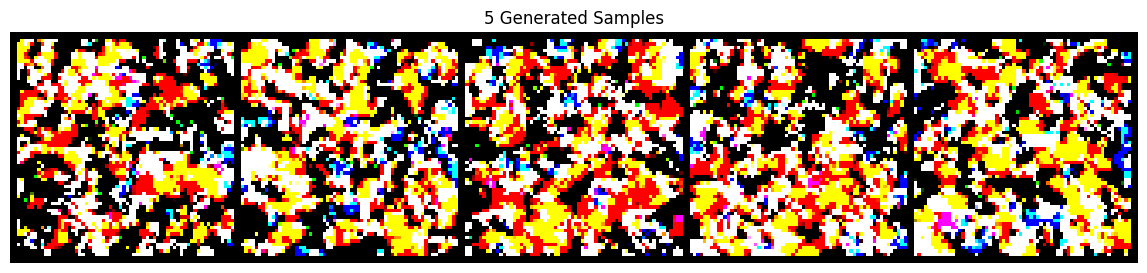

In [75]:
# Select the first 5 samples
images_to_show = samples[:5].cpu()
# Make a grid of 5 images (1 row, 5 columns)
grid = torchvision.utils.make_grid(images_to_show, nrow=5)
# Convert to NumPy for displaying with matplotlib
np_grid = grid.permute(1, 2, 0).numpy()
# Plot
plt.figure(figsize=(15, 3))
plt.imshow(np_grid)
plt.axis('off')
plt.title("5 Generated Samples")
plt.show()

 Next Steps Suggested
Improve training stability: Use techniques like spectral normalization, gradient clipping, or better initialization.

Tune hyperparameters: Adjust learning rate, batch size, and training steps.